# The quantile recursion as an adapted generator

One run, end to end, with the reasoning next to the code.  This notebook is the
blueprint: `quantile_learning.py` does exactly the same thing for every point of
a grid, so anything that is unclear here will be unclear there too.

**It reads `config.py` and takes the first element of every vector.**  Nothing
is configured in this notebook.  To change the run, edit `config.py`.

### What is being claimed

The target is a stationary process on $\mathcal X = [-M, M]$ whose one-step
conditional quantile given the past satisfies a one-sided Dobrushin condition,

$$|q(u;z) - q(u;z')| \;\le\; \sum_{i\ge1}\ell_i\,|z_i - z'_i|,
\qquad S = \sum_i \ell_i < 1 .$$

Fit an approximate conditional quantile $\hat q$ at arity $m$ and close it into
a recursion driven by i.i.d. uniforms,
$\hat X_t = \hat q(u_t;\hat X_{t-1},\dots,\hat X_{t-m})$.  Then the generated
process is stationary and ergodic, is a function of the innovations alone with
no window, seed or burn-in, and its law satisfies

$$\mathcal{A}W_p^w(\mu,\hat\mu)\;\le\;\frac{\theta + 2M L_{m+1}}{1 - S_m},
\qquad \theta = \sup_{u,z}|\hat q - q_m|,\quad
L_{m+1} = \sum_{i>m}\ell_i,$$

for every $p$ and every weight sequence, with the constant carrying the
**target's** contraction and nothing assumed of $\hat q$ beyond continuity.
Monotonicity in $u$ and contractivity are free, by the repair lemma.

Two choices in this package follow from that statement and are worth stating
before any code runs.

**$S$ is an input.**  Every target is built at exactly the $S$ you ask for, by
solving for one amplitude; its *shape* (which kind of dependence it has) is
fixed separately.  So $S$ is an axis and "same $S$, different mechanism" is a
fair comparison.

**$m$ is what you presume, not the truth.**  It is never silently raised to the
target's own memory order.  Fitting below the truth is legitimate and is priced
by $L_{m+1}$, uniformly: a two-lag linear target at $m=1$ is misspecified in
exactly the way, and by exactly the term, that a long-memory target at $m=4$ is.

## 0. Setup

In [1]:
import os, sys, time, json
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import config as CFG
torch.set_num_threads(getattr(CFG, "TORCH_THREADS", 2))

from generators.synthetic_generators import build_target
from generators.quantile_generator import ClosedQuantileRecursion
from generators.esn_realization import ESNRealization
from generators.simulate_paths import simulate, make_windows, shared_pair, initial_spread
from fit_generator import fit
from loss.mmd import blocks, permutation_test
from utils.hypotheses import verify_assumptions, hypothesis_report
from utils.repair import repair_report
from utils.pathwise import pathwise_report, synchronisation_report
from utils.lyapunov import lyapunov, lyapunov_decomposition
from utils.autocorrelation import acf_report
from utils.marginal import marginal_report
from utils.conditional import conditional_report
from utils.pricing import pricing_report
from utils.baselines import MatchedGaussianAR
from utils.plotting import C_TARGET, C_GEN, C_BASE

print("torch", torch.__version__, "| numpy", np.__version__)

torch 2.2.2 | numpy 1.26.4


In [2]:
%load_ext autoreload
%autoreload 2

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
dtype = torch.float64

### The configuration for this run

The first element of every vector in `config.py`.  A one-element vector is a
fixed setting; a longer one becomes an axis of the sweep that
`quantile_learning.py` runs.

In [3]:
first = lambda d: {k: v[0] for k, v in d.items()}
DATA, NET, TRAIN, EVAL = first(CFG.DATA), first(CFG.NET), first(CFG.TRAIN), first(CFG.EVAL)

TARGET   = CFG.TARGETS[0]
m        = int(CFG.M[0])          # the LEARNER's lag dimension
S_TARGET = float(CFG.S_TARGET[0]) # matched exactly by the target
M        = float(DATA["M_state"])
SHAPE    = CFG.TARGET_SPECIFICS[TARGET]

for nm, d in (("target", {"target": TARGET, "m": m, "S_target": S_TARGET}),
              ("shape (fixed)", SHAPE), ("data", DATA), ("net", NET),
              ("train", TRAIN), ("eval", EVAL)):
    print(f"{nm:>14}  {d}")
if len(CFG.TARGETS) * len(CFG.M) * len(CFG.S_TARGET) > 1:
    print(f"\nconfig.py describes a grid; this notebook runs only the first point.")

        target  {'target': 'linear', 'm': 2, 'S_target': 0.75}
 shape (fixed)  {'profile': [0.45, 0.2]}
          data  {'T_train': 60000, 'burn': 2000, 'seed_path': 1, 'M_state': 1.0, 'noise': 'truncnorm'}
           net  {'width': 256, 'act': 'softclip', 'seed_net': 0, 'v_mode': 'u', 'v_clip': 2.5}
         train  {'objective': 'pinball', 'epochs': 300, 'batch': 512, 'lr': 0.003, 'lip_mode': 'penalty', 'pen_region': 'hood', 'pen_sigma': 0.15, 'L_max': 0.95, 'lam': 1.0, 'tail_frac': 0.2, 'edge': 0.02, 'u_min': 0.0001, 'mmd_block': 4, 'mmd_batch': 256, 'mmd_burn': 32}
          eval  {'T_eval': 40000, 'seed_eval': 99, 'T_shared': 20000, 'seed_shared': 7, 'n_starts': 24, 'n_spread_steps': 80, 'block_len': 4, 'block_stride': 1, 'n_perm': 150, 'mmd_max_n': 900, 'n_bins': 18, 'strike': 0.1, 'n_exercise': 5}

config.py describes a grid; this notebook runs only the first point.


## 1. The target

Built at exactly the requested $S$.  Three things to read off:

* `ell` the per-lag moduli, and `S_m` the mass the fit can see at arity $m$;
* `L_tail` $=\sum_{i>m}\ell_i$, the mass the $m$-anchored truncation drops.  It
  is zero only when $m$ reaches the target's own order;
* the finite-difference check, which should agree with the analytic moduli.  A
  gap of order $10^{-3}$ on ARCH and the logistic target is expected rather than
  wrong: their moduli are attained at a corner of the box that random sampling
  approaches without hitting.

In [4]:
target = build_target(TARGET, S_TARGET, SHAPE, M=M, noise=DATA["noise"])
print(target.name)
print(f"  requested S {S_TARGET}   achieved {target.S:.8f}")
print(f"  target's own memory order: {target.k_true if target.k_true is not None else 'infinite'}")
print(f"  fitting arity m = {m}")
print(f"  ell[:8]   {np.round(target.moduli(8), 4).tolist()}")
print(f"  S_m       {target.S_m(m):.4f}      amplification 1/(1-S_m) = "
      f"{1/(1-target.S_m(m)):.3f}" if target.S_m(m) < 1 else "  S_m >= 1")
print(f"  L_(m+1)   {target.L_tail(m):.4f}   truncation term 2 M L = {target.truncation_term(m):.4f}")

chk = verify_assumptions(target, m=m)
dev = max(abs(a - b) for a, b in zip(chk["ell_analytic"], chk["ell_numeric"]))
print(f"\n  moduli, analytic vs finite difference: max deviation {dev:.2e}")
print(f"  range contained in [-M, M]: {chk['in_range']}  "
      f"[{chk['range_min']:.4f}, {chk['range_max']:.4f}]")

Linear(k=2, S=0.750)
  requested S 0.75   achieved 0.75000000
  target's own memory order: 2
  fitting arity m = 2
  ell[:8]   [0.5192, 0.2308, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  S_m       0.7500      amplification 1/(1-S_m) = 4.000
  L_(m+1)   0.0000   truncation term 2 M L = 0.0000

  moduli, analytic vs finite difference: max deviation 2.37e-13
  range contained in [-M, M]: True  [-0.9426, 0.9684]


## 2. The observed path

Simulated at the target's **own** memory order, never at $m$.  That matters:
the experiment is "fit at $m$, compare against the real process", not "fit at
$m$, compare against an $m$-lag caricature".  Getting this wrong once made an
earlier set of ARMA and long-memory runs test nothing.

T = 60000   mean -0.0002   sd 0.1545   range [-0.565, 0.583]   (0.1s)


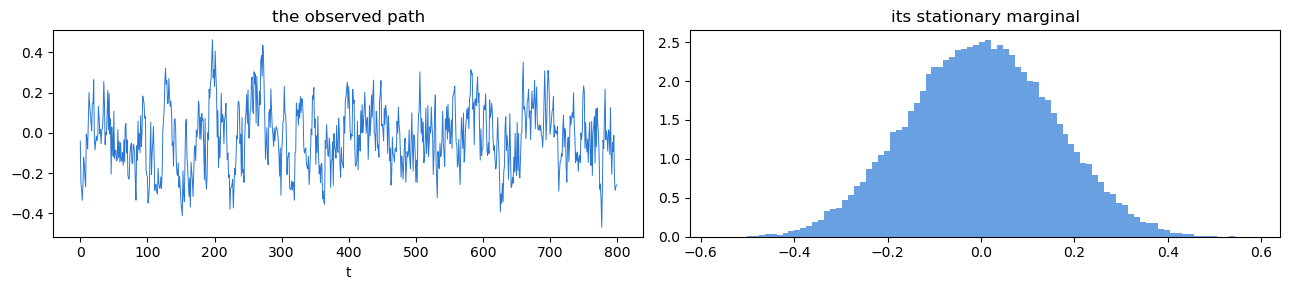

In [5]:
t0 = time.time()
path = simulate(target, DATA["T_train"], burn=DATA["burn"], seed=DATA["seed_path"])
print(f"T = {len(path)}   mean {path.mean():+.4f}   sd {path.std():.4f}   "
      f"range [{path.min():.3f}, {path.max():.3f}]   ({time.time()-t0:.1f}s)")

fig, ax = plt.subplots(1, 2, figsize=(13, 3))
ax[0].plot(path[:800], lw=.7, color=C_TARGET); ax[0].set_title("the observed path"); ax[0].set_xlabel("t")
ax[1].hist(path, bins=90, density=True, color=C_TARGET, alpha=.7); ax[1].set_title("its stationary marginal")
plt.tight_layout(); plt.show()

## 3. The supervised dataset

One pair $(z_t, x_t)$ per time step, $z_t = (X_{t-1},\dots,X_{t-m})$.  There is
**one observation per conditioning window**, which is the whole difficulty: the
conditional law at $z$ is never observed, only one draw from it.  The pinball
criterion works anyway because it is a strictly consistent scoring function for
the quantile pointwise in the level.

In [6]:
Z, Xs = make_windows(path, m)
print(f"Z {Z.shape}   X {Xs.shape}   (one draw per conditioning window)")

Z (59998, 2)   X (59998,)   (one draw per conditioning window)


## 4. Fit

The objective is the randomised pinball loss, i.e. half the continuous ranked
probability score of the conditional law.  Two settings deserve a word.

**`tail_frac`.**  A fraction of the training levels is drawn log-uniformly in
the tails.  Any positive weight on the levels keeps the criterion proper
pointwise in $u$, so this is a change of resolution and not of estimand.  It is
needed because $dq/du$ at $u = 0.001$ is several times its value at the median
for a truncated-normal innovation, so uniform levels put almost no signal where
the conditional quantile is steepest.

**`pen_region="hood"`.**  The Lipschitz penalty is applied near the data rather
than on uniform draws from the whole box.  The hinge is a maximum over the
batch, so on box draws it fires at points the recursion never visits and, at a
finite budget, drives the fitted map flatter than the truth.  That was the main
cause of the tail problem: at `L_max = 0.85` and `lam = 5` the fitted sum of lag
sensitivities came out at 0.62 against a target $S$ of 0.705, and both the
generated tails and the volatility clustering were short.

In [ ]:
lip_mode = TRAIN["lip_mode"]
if target.S >= 1.0 and lip_mode != "none":
    print(f"NOTE: the target has S = {target.S:.3f} >= 1, so the Lipschitz penalty "
          f"is switched off: a contractive fit cannot approximate an expansive target.")
    lip_mode = "none"

net, fitinfo = fit(Z, Xs, m,
                   objective=TRAIN["objective"], width=NET["width"], act=NET["act"],
                   seed_net=NET["seed_net"], v_mode=NET["v_mode"], v_clip=NET["v_clip"],
                   epochs=TRAIN["epochs"], batch=TRAIN["batch"], lr=TRAIN["lr"],
                   lip_mode=lip_mode, pen_region=TRAIN["pen_region"],
                   pen_sigma=TRAIN["pen_sigma"], L_max=TRAIN["L_max"], lam=TRAIN["lam"],
                   tail_frac=TRAIN["tail_frac"], edge=TRAIN["edge"], u_min=TRAIN["u_min"],
                   M=M, verbose=True, log_every=max(1, TRAIN["epochs"] // 10))
print(f"\nfinal loss {fitinfo['final_loss']:.6f}   ({fitinfo['secs']:.0f}s)")

h = fitinfo["history"]
fig, ax = plt.subplots(1, 2, figsize=(12, 3))
ax[0].plot([e["loss"] for e in h], color=C_GEN); ax[0].set_title("training loss"); ax[0].set_xlabel("epoch")
ax[1].plot([e["lip_box"] for e in h], color=C_GEN, label=r"$\sum_i$Lip$_i(\hat q)$ measured")
ax[1].axhline(TRAIN["L_max"], color="#52514e", ls="--", lw=1, label="L_max (the cap)")
ax[1].axhline(target.S_m(m), color=C_TARGET, ls=":", lw=1.4, label=r"$S_m$ (the target)")
ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=8, frameon=False)
ax[1].set_title("does the fit inherit the contraction?")
plt.tight_layout(); plt.show()

  epoch    0   loss 0.08566   sum_i Lip_i on the state space 1.187
  epoch   30   loss 0.02633   sum_i Lip_i on the state space 1.073
  epoch   60   loss 0.02590   sum_i Lip_i on the state space 0.936
  epoch   90   loss 0.02572   sum_i Lip_i on the state space 0.839
  epoch  120   loss 0.02575   sum_i Lip_i on the state space 0.859
  epoch  150   loss 0.02562   sum_i Lip_i on the state space 0.988
  epoch  180   loss 0.02546   sum_i Lip_i on the state space 0.978


## 5. The hypotheses, measured

$\theta$ is reported on three domains and they are not the same number.

* **data support** — what the bound below uses, and the honest quantity: the
  recursion never visits the corners of the box.
* **box** $[-M,M]^m$ — what the proposition as usually stated asks for.  In the
  earlier study this ran 1.7 to 7.8 times larger.
* **the forward-invariant set** $K = [-R,R]^m$ with $\hat q(u;K^m)\subseteq K$ —
  the refinement: weaker than the box, still checkable, and all the proof
  actually uses, since it only ever evaluates $q$ and $\hat q$ where the two
  processes are.

$\theta$ is also a supremum over levels, and the extreme levels dominate it;
the trimmed values show by how much.  That gap is the uniformity-in-$u$ cost and
no change of domain removes it.

In [ ]:
rp = repair_report(net, Z, M=M)
hy = hypothesis_report(net, target, Z, m, M=M, inv_R=rp["inv_R"])

print(f"  S_m (target)         {hy['S_m']:.4f}")
print(f"  sum_i Lip_i (fit)    box {hy['lip_box']:.4f}   data support {hy['lip_data']:.4f}")
print(f"  per lag, box         {np.round(hy['lip_per_lag_box'][:8], 4).tolist()}")
print()
print(f"  theta, data support  {hy['theta_data']:.4f}   <- the bound uses this")
print(f"  theta, box           {hy['theta_box']:.4f}   ({hy['theta_box']/max(hy['theta_data'],1e-12):.1f}x larger)")
if "theta_invariant" in hy:
    print(f"  theta, K=[-R,R]^m    {hy['theta_invariant']:.4f}   with R = {rp['inv_R']:.3f}")
print(f"  theta trimmed        " + "   ".join(f"eps={k}: {v:.4f}" for k, v in hy["theta_trim"].items()))
print()
print(f"  bound (theta + 2 M L_(m+1)) / (1 - S_m) = {hy['bound']:.4f}")

plt.figure(figsize=(6.5, 3))
plt.plot(hy["theta_profile_u"], hy["theta_profile_err"], color=C_GEN)
plt.axhline(hy["theta_data"], color="#52514e", ls="--", lw=.9)
plt.xlabel("$u$"); plt.title(r"$\max_z |\hat q - q_m|$ by level")
plt.tight_layout(); plt.show()

## 6. Is the repair lemma doing anything?

Monotonicity in $u$ and $\mathcal X$-invariance are not imposed during
training, because the repair lemma supplies the rearrangement $R$, a Lipschitz
regularisation $T$ and the projection $\Pi_{\mathcal X}$ free, each nonexpansive
in the uniform norm so $\theta$ cannot grow.  The question is whether any of
them is needed.

**The two domains differ and the table would otherwise look self-contradictory.**
Crossings are measured on the data support; the minimum of $\partial\hat q/
\partial u$ and $\sup|\hat q|$ on the whole box.  A fit can be monotone where
the process lives and not monotone in a corner, and in the earlier study three
of twenty-one were.

In [ ]:
print(f"  crossings on the data support   fraction {rp['cross_frac']:.3e}   "
      f"worst increment {rp['cross_worst']:+.2e}")
print(f"  min d qhat / du on the box      {rp['du_min']:+.4f}   (monotone there iff >= 0)")
print(f"  sup |qhat| on the box           {rp['sup_q_box']:.4f}   X-valued: {rp['box_invariant']}")
print(f"  smallest invariant radius R     {rp['inv_R']:.3f}   (sup|qhat| there {rp['inv_sup']:.3f})")
print(f"\n  repairs needed: {', '.join(rp['repairs_needed'])}")

## 7. The closed recursion, and uniqueness seen directly

Close the fitted map into a recursion driven by fresh uniforms.  Then start it
from 24 different initial states under **one shared** innovation stream: if the
solution of the closed recursion is unique, the trajectories must forget where
they started and the spread must collapse.

Note what governs this.  Not $S_m < 1$, which is a supremum, but the top
Lyapunov exponent, which is an average of a log.  In the noise-budget sweep the
spread was still $9\times10^{-11}$ at $S = 2.0$, and only failed once the
exponent crossed zero.

In [ ]:
rec = ClosedQuantileRecursion(net)
sy = synchronisation_report(rec, M=M, n_steps=EVAL["n_spread_steps"], n_starts=EVAL["n_starts"])
lam_val, lam_exact = lyapunov(net, simulate(rec, 20000, burn=2000, seed=5))

print(f"  spread across {sy['n_starts']} starts   "
      f"t={sy['n_steps']//2}: {sy['spread_half']:.3e}   t={sy['n_steps']-1}: {sy['spread_end']:.3e}")
print(f"  E log sum_i |d qhat / d z_i| = {lam_val:+.4f}   "
      + ("(exactly the top Lyapunov exponent, m = 1)" if lam_exact
         else "(an upper bound for the top exponent, m > 1)"))

plt.figure(figsize=(6.5, 3))
plt.semilogy(np.maximum(sy["spread"], 1e-18), color=C_GEN, marker="o", ms=3)
plt.xlabel("t"); plt.title("spread across 24 initial states, one shared stream")
plt.tight_layout(); plt.show()

## 8. The pathwise bound, under the synchronous coupling

Drive target and learned recursion with the **same** stream.  Both are adapted
to the innovations and closed in their own observable, so the coupling is
bicausal and

$$\sup_t |X_t - \hat X_t| \;\ge\; \mathcal{A}W_\infty(\mu,\hat\mu),$$

that is, the realised quantity is an upper bound for the adapted distance, and
the comparison lemma bounds it above in turn.  Expect slack: in the earlier
study it ran between 3 and 20.  It decomposes, and only part of it is
removable: $2M$ is the diameter of the state space where the recursion only
traverses something of the order of the stationary spread, and separately a
supremum over $t$ of a weighted sum is not the sum of the suprema.

In [ ]:
pw = pathwise_report(target, rec, hy["theta_data"], m,
                     n=EVAL["T_shared"], burn=DATA["burn"], seed=EVAL["seed_shared"])
print(f"  sup_t |X - Xhat|   {pw['sup_err']:.4f}     mean {pw['mean_err']:.4f}     "
      f"99.9pct {pw['q999_err']:.4f}")
if pw["bound"]:
    print(f"  bound              {pw['bound']:.4f}   slack x{pw['slack']:.1f}   holds: {pw['bound_holds']}")
    print(f"    = (theta {pw['theta']:.4f} + 2ML {pw['truncation_term']:.4f}) "
          f"x amplification {pw['amplification']:.3f}")
else:
    print("  bound void: S_m >= 1")

plt.figure(figsize=(9, 3))
plt.semilogy(np.maximum(pw["err_head"], 1e-14), lw=.7, color=C_GEN, label=r"$|X_t-\hat X_t|$")
if pw["bound"]:
    plt.axhline(pw["bound"], color="#e34948", ls="--", lw=1.3, label="the bound")
plt.xlabel("t"); plt.legend(fontsize=8, frameon=False); plt.tight_layout(); plt.show()

## 9. The two laws, on fresh independent streams

Everything from here uses **unrelated** innovations on the two sides, so the
comparisons are law-level and not artefacts of a shared driver.

The baseline is a Gaussian AR($m$) fitted to the same training path.  It
reproduces the linear autocorrelation by construction and has a constant
conditional spread, also by construction, so it is the model that passes every
standard second-order diagnostic and gets the conditional structure wrong.  On
an affine, near-Gaussian target it should and does win on the marginal; that is
the correct outcome, not a defect.

In [ ]:
tru  = simulate(target, EVAL["T_eval"], burn=DATA["burn"], seed=EVAL["seed_eval"])
gen  = simulate(rec,    EVAL["T_eval"], burn=DATA["burn"], seed=EVAL["seed_eval"] + 1)
base = MatchedGaussianAR(p=m).fit(path).simulate(EVAL["T_eval"], burn=DATA["burn"],
                                                 seed=EVAL["seed_eval"] + 2)

STATE_DEP = {"hetero", "arch", "oscillatory"}
mg = marginal_report(tru, gen, base)
ac = acf_report(tru, gen, base)
cd = conditional_report(tru, gen, base, n_bins=EVAL["n_bins"],
                        scale_is_state_dependent=(TARGET in STATE_DEP))

print(f"  sd            target {mg['sd_tru']:.4f}   generated {mg['sd_gen']:.4f}   ratio {mg['sd_ratio']:.4f}")
print(f"  W1 / sd       generated {mg['w1_over_sd']:.4f}   matched AR {mg['w1_over_sd_base']:.4f}")
print(f"  cond W1       generated {cd['cond_w1']:.5f}   matched AR {cd['cond_w1_base']:.5f}")
print(f"  ACF   lag1    {ac['acf_tru'][1]:+.4f} / {ac['acf_gen'][1]:+.4f} / {ac['acf_base'][1]:+.4f}  (tru/gen/AR)")
print(f"  ACFsq lag1    {ac['acfsq_tru'][1]:+.4f} / {ac['acfsq_gen'][1]:+.4f} / {ac['acfsq_base'][1]:+.4f}")
print()
print("  marginal quantiles, error in sd units (the ratio is unreliable near zero)")
for q in mg["quantiles"]:
    print(f"    {q['level']:6.3f}  target {q['target']:+.4f}  generated {q['generated']:+.4f}  "
          f"err/sd {q['err_over_sd']:+.4f}")

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(19, 3.3))
bb = np.linspace(min(tru.min(), gen.min()), max(tru.max(), gen.max()), 90)
ax[0].hist(tru, bins=bb, density=True, alpha=.55, color=C_TARGET, label="target")
ax[0].hist(gen, bins=bb, density=True, alpha=.55, color=C_GEN, label="generated")
ax[0].set_title(f"marginal   $W_1$/sd = {mg['w1_over_sd']:.4f}"); ax[0].legend(fontsize=8, frameon=False)

lv = [q["level"] for q in mg["quantiles"]]
ax[1].plot(lv, [q["err_over_sd"] for q in mg["quantiles"]], "s--", color=C_GEN, label="generated")
ax[1].plot(lv, [q["err_over_sd"] for q in mg["quantiles_base"]], "^:", color=C_BASE, label="matched AR")
ax[1].axhline(0, color="#52514e", lw=.8); ax[1].set_xscale("logit")
ax[1].set_title(r"quantile error $(\hat q_\alpha - q_\alpha)/$sd"); ax[1].legend(fontsize=8, frameon=False)

for a, key, ttl in ((ax[2], "acf", "ACF of $X_t$"), (ax[3], "acfsq", r"ACF of $(X_t-\bar X)^2$")):
    a.plot(ac[f"{key}_tru"], "o-", color=C_TARGET, ms=3, label="target")
    a.plot(ac[f"{key}_gen"], "s--", color=C_GEN, ms=3, label="generated")
    a.plot(ac[f"{key}_base"], "^:", color=C_BASE, ms=3, label="matched AR")
    a.axhline(0, color="#52514e", lw=.8); a.set_xlabel("lag"); a.set_title(ttl)
    a.legend(fontsize=8, frameon=False)
plt.tight_layout(); plt.show()

### The conditional law

The diagnostic a path-law metric cannot see.  Two readings:

* the **conditional standard deviation** per bin, which sees a state-dependent
  scale and is pure sampling noise on a homoskedastic target.  Read the range
  only on `hetero`, `arch` and `oscillatory`;
* the **conditional $W_1$**, aggregated by occupancy.  In the earlier study this
  was the most stable statistic of all, 2 to 4 per cent relative standard
  deviation across seeds against 11 to 32 per cent for $\theta$, and the only
  one that sees the `skew` target, whose conditional skewness varies while its
  mean and variance do not.

In [ ]:
if cd.get("note"):
    print("NOTE:", cd["note"])
print(f"  cond sd range   target {cd['cond_sd_range_tru']:.4f}   generated {cd['cond_sd_range_gen']:.4f}"
      f"   matched AR {cd['cond_sd_range_base']:.4f}")
print(f"  cond W1         generated {cd['cond_w1']:.5f}   matched AR {cd['cond_w1_base']:.5f}")

mid = np.array(cd["mid"])
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].plot(mid, cd["cond_sd_tru"], "o-", color=C_TARGET, ms=3, label="target")
ax[0].plot(mid, cd["cond_sd_gen"], "s--", color=C_GEN, ms=3, label="generated")
ax[0].plot(mid, cd["cond_sd_base"], "^:", color=C_BASE, ms=3, label="matched AR")
ax[0].set_xlabel("$X_{t-1}$"); ax[0].set_title("conditional sd"); ax[0].legend(fontsize=8, frameon=False)
ax[1].plot(mid, cd["cond_w1_profile"], "s--", color=C_GEN, ms=3)
ax[1].set_xlabel("$X_{t-1}$"); ax[1].set_title(r"conditional $W_1$ per bin")
plt.tight_layout(); plt.show()

## 10. Why the path-law diagnostics are not enough

A block-MMD on windows of length 4 sees the joint law of four consecutive
states; it is a path-law criterion and the counterexample behind the adapted
distance applies to it unchanged.  Failure to reject is not evidence of
equality.

The early-exercise premium is the number that cannot be got right without the
conditional structure: a European claim depends on a marginal, a Bermudan on
what is *predictable* from the observed path.  Two laws within $\varepsilon$ in
every $W_p$, $p=\infty$ included, can differ by one half in the value of a
two-period Bermudan.

In [ ]:
L, st = EVAL["block_len"], EVAL.get("block_stride", 1)
bt = blocks(tru, L, st)
mm_gen  = permutation_test(bt, blocks(gen,  L, st), n_perm=EVAL["n_perm"], max_n=EVAL["mmd_max_n"])
mm_base = permutation_test(bt, blocks(base, L, st), n_perm=EVAL["n_perm"], max_n=EVAL["mmd_max_n"])
print(f"  block-MMD^2 (L={L})   generated {mm_gen['mmd2']:+.6f}  p={mm_gen['p_value']:.3f}")
print(f"                        matched AR {mm_base['mmd2']:+.6f}  p={mm_base['p_value']:.3f}")

pr = pricing_report(tru, gen, base, K=EVAL["strike"], n_exercise=EVAL["n_exercise"])
print(f"\n  European put    target {pr['target']['european']:.5f}   "
      f"generated {pr['generated']['european']:.5f}   AR {pr['baseline']['european']:.5f}")
print(f"  Bermudan put    target {pr['target']['bermudan']:.5f}   "
      f"generated {pr['generated']['bermudan']:.5f}   AR {pr['baseline']['bermudan']:.5f}")
print(f"  PREMIUM         target {pr['target']['premium']:.5f}   "
      f"generated {pr['generated']['premium']:.5f}   AR {pr['baseline']['premium']:.5f}")
print(f"  relative error on the premium: {pr['premium_rel_err']:+.4f}")

## 11. The echo state network realisation

The fitted map is a readout of $(u, z)$ with $z$ the last $m$ outputs.  An
ordinary ESN carries the reservoir state, not its own output window, which is
exactly why the filter route is causal but not bicausal.  Making part of the
reservoir an **exact** shift register rather than an approximate one closes
that gap: the state becomes a linear image of the last $m$ outputs and the
recursion the network runs *is* the quantile recursion.

The shift units carry zero input weight and their pre-activations stay inside
the interval on which the activation is affine, which is why the activation
must be affine on an interval and why $\tanh$ provably will not do.  The error
below should be at machine precision, not merely small.

In [ ]:
if NET["act"] == "softclip":
    esn = ESNRealization(net, operating_radius=1.6 * M)
    err = esn.realisation_error(rec, n=2000, burn=500)
    print(f"  max |ESN - direct recursion| = {err:.3e}")
    print(f"  {esn.info()}")
    print("  (W quantile units + (m-1) shift units + 1 constant unit)")
else:
    print(f"  skipped: the exact shift needs the softclip activation, not {NET['act']!r}")

## 12. Summary

In [ ]:
print(f"target            {target.name}")
print(f"fitting arity m   {m}   (target's own order: "
      f"{target.k_true if target.k_true is not None else 'infinite'})")
print(f"S requested       {S_TARGET}      achieved {target.S:.6f}")
print(f"S_m / L_(m+1)     {target.S_m(m):.4f} / {target.L_tail(m):.4f}")
print(f"theta (data)      {hy['theta_data']:.4f}")
print(f"bound             {hy['bound']:.4f}")
print(f"realised sup err  {pw['sup_err']:.4f}" + (f"   slack x{pw['slack']:.1f}" if pw['slack'] else ""))
print(f"W1 / sd           {mg['w1_over_sd']:.4f}   (matched AR {mg['w1_over_sd_base']:.4f})")
print(f"conditional W1    {cd['cond_w1']:.5f}   (matched AR {cd['cond_w1_base']:.5f})")
print(f"ACFsq lag-1       {ac['acfsq_tru'][1]:+.4f} target / {ac['acfsq_gen'][1]:+.4f} generated")
print(f"block-MMD p       {mm_gen['p_value']:.3f}")
print(f"repairs needed    {', '.join(rp['repairs_needed'])}")

### What this shows, and what it does not

It shows that one fitted conditional quantile, closed into a recursion driven
by nothing but i.i.d. uniforms, reproduces the target's law; that the pathwise
bound holds; and that the realisation inside an echo state network is exact.

It does not show that the bound is of the right order.  The realised
$\sup_t|X_t-\hat X_t|$ is an upper bound for the adapted distance and the
theorem bounds it above in turn; nothing here produces a lower bound, so a
large slack means the bound is loose and nothing more.  $\theta$ is a maximum
over a grid, not a supremum.  The block-MMD has real but limited power.  And
this is one seed: run `quantile_learning.py` with several `seed_path` and
`seed_net` values before quoting any single number.

**To run the grid**, edit `config.py` and then

```
python quantile_learning.py --dry-run     # see the grid
python quantile_learning.py --quick       # shake out the pipeline, ~3 s a run
python quantile_learning.py               # the real thing
```